In [1]:
#Import libraries and dependencies

import sys
import os
import glob
import csbdeep
import tensorflow as tf
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from stardist.models import StarDist2D

print("Python:", sys.executable)

2026-09-14 15:10:39.528037: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-14 15:10:39.594415: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-14 15:10:39.641813: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-14 15:10:39.641971: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-14 15:10:39.696932: I tensorflow/core/platform/cpu_feature_gua

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2026-09-14 15:10:41.208889: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Python: /home/rootwsl2/miniconda3/envs/stardist/bin/python


In [ ]:
#Import stardist model

model = StarDist2D(
    None,
    name="Model",
    basedir="/mnt/c/Users/hbruce/Desktop/stardist_cIN_model" #input path to the model here
)
print("Model loaded successfully")

In [3]:
#Set up input/output folders for batch analysis


INPUT_DIR = "/mnt/c/Users/hbruce/Desktop/stardist_cIN_model/stardist_input" #Change accordingly 
OUTPUT_DIR = "/mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output" #Change accordingly 
STATS_OUTPUT_DIR = "/mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/stats" #Change accordingly

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(STATS_OUTPUT_DIR, exist_ok=True)

input_paths = sorted(glob.glob(os.path.join(INPUT_DIR, "*.tif")))

# Tracking / analysis parameters applied to every movie
MAX_DISPLACEMENT_UM = 50.0 #For tracking I allow cells to be absent for one frame, with a max displacement of 60um 

MAX_FRAME_GAP = 1 #allow an onject to be missed for this many consecutive frames

#Nucleokinesis analysis
NUCLEOKINESIS_THRESHOLD_UM = 5.0

#Pause threshold
PAUSE_THRESHOLD_UM = 0.5

#Minimum tracking duration
MIN_TRACK_DURATION_HOURS = 5.0

#Polarity measurements
REVERSAL_ANGLE_THRESHOLD_DEG = 135.0
N_TILES = (2, 2)

print(f"Found {len(input_paths)} movie(s) to process:")
for p in input_paths:
    print(" ", os.path.basename(p))

Found 8 movie(s) to process:
  HB_E13_MGE_Sex_02032026_Embryo1_Female.tif
  HB_E13_MGE_Sex_02032026_Embryo2_Male.tif
  HB_E13_MGE_Sex_02032026_Embryo3_Male.tif
  HB_E13_MGE_Sex_02032026_Embryo4_Female.tif
  HB_E13_MGE_Sex_02032026_Embryo5_Female.tif
  HB_E13_MGE_Sex_02032026_Embryo6_Male.tif
  HB_E13_MGE_Sex_02032026_Embryo7_Male.tif
  HB_E13_MGE_Sex_02032026_Embryo8_Female.tif


In [4]:
#Function to read and calibrate tiff metadata

def read_calibrated_tiff(input_path):
    """Read a timelapse TIFF and pull out its ImageJ calibration."""
    with tifffile.TiffFile(input_path) as tif:
        movie = tif.asarray()
        imagej_metadata = dict(tif.imagej_metadata) if tif.imagej_metadata else {}
        page0 = tif.pages[0]

        x_resolution = page0.tags["XResolution"].value if "XResolution" in page0.tags else None
        y_resolution = page0.tags["YResolution"].value if "YResolution" in page0.tags else None
        resolution_unit = page0.tags["ResolutionUnit"].value if "ResolutionUnit" in page0.tags else None

    unit = imagej_metadata.get("unit")
    spacing = imagej_metadata.get("spacing")
    frame_interval = imagej_metadata.get("finterval")
    labels = imagej_metadata.get("Labels")

    if unit != "micron" or x_resolution is None or y_resolution is None:
        raise ValueError(
            f"{os.path.basename(input_path)}: missing or unsupported spatial "
            f"calibration (unit={unit})"
        )

    x_res = x_resolution[0] / x_resolution[1]
    y_res = y_resolution[0] / y_resolution[1]
    pixels_per_micron = (x_res + y_res) / 2.0

    return {
        "movie": movie,
        "imagej_metadata": imagej_metadata,
        "x_resolution": x_resolution,
        "y_resolution": y_resolution,
        "resolution_unit": resolution_unit,
        "unit": unit,
        "spacing": spacing,
        "frame_interval": frame_interval,
        "labels": labels,
        "pixels_per_micron": pixels_per_micron,
    }

In [5]:
#define function to run stardist segmentation on a single timelapse series

def run_stardist_on_movie(movie, model, n_tiles=(2, 2)):
    all_labels = []
    all_points = []

    for t in range(movie.shape[0]):
        frame = movie[t].astype(np.float32)
        labels, details = model.predict_instances(frame, n_tiles=n_tiles)

        all_labels.append(labels)
        all_points.append(details["points"])

        print(f"    frame {t + 1}/{movie.shape[0]}: {len(details['points'])} objects")

    return all_labels, all_points

In [6]:
#Define function to save segmentation stacks with original metadata from .tif file

def save_segmentation(all_labels, calib, input_path, output_dir):
    segmentation = np.stack(all_labels).astype(np.uint16)

    output_metadata = dict(calib["imagej_metadata"])
    output_metadata["images"] = segmentation.shape[0]
    output_metadata["frames"] = segmentation.shape[0]
    if calib["spacing"] is not None:
        output_metadata["spacing"] = calib["spacing"]
    if calib["unit"] is not None:
        output_metadata["unit"] = calib["unit"]
    if calib["frame_interval"] is not None:
        output_metadata["finterval"] = calib["frame_interval"]
    if calib["labels"] is not None:
        output_metadata["Labels"] = calib["labels"]
    if "Properties" in calib["imagej_metadata"]:
        output_metadata["Properties"] = calib["imagej_metadata"]["Properties"]

    basename = os.path.splitext(os.path.basename(input_path))[0]
    output_path = os.path.join(output_dir, basename + "_stardist_segmentation.tif")

    write_kwargs = {"imagej": True, "metadata": output_metadata}
    if calib["x_resolution"] is not None and calib["y_resolution"] is not None:
        write_kwargs["resolution"] = (calib["x_resolution"], calib["y_resolution"])
    if calib["resolution_unit"] is not None:
        write_kwargs["resolutionunit"] = calib["resolution_unit"]

    tifffile.imwrite(output_path, segmentation, **write_kwargs)
    return output_path

In [7]:
#Function to define how each timelapse is tracked - Hungarian-assignment tracking based 

def track_points(all_points, pixels_per_micron, max_displacement_um, max_frame_gap= MAX_FRAME_GAP):
    """Hungarian-assignment tracker."""

    max_displacement_px = max_displacement_um * pixels_per_micron

    tracks = []
    next_track_id = 1
    active_tracks = []  # each: {track_id, y, x, last_frame, frames_missed}

    def record(track_id, frame, detection_idx, y, x):
        tracks.append({"track_id": track_id, "frame": frame, "detection": detection_idx,
                        "y": float(y), "x": float(x)})

    for detection_idx, (y, x) in enumerate(all_points[0]):
        track_id = next_track_id
        record(track_id, 0, detection_idx, y, x)
        active_tracks.append({"track_id": track_id, "y": float(y), "x": float(x),
                               "last_frame": 0, "frames_missed": 0})
        next_track_id += 1

    for frame in range(1, len(all_points)):
        current_points = np.asarray(all_points[frame], dtype=float)

        if len(current_points) == 0:
            for t in active_tracks:
                t["frames_missed"] += 1
            active_tracks = [t for t in active_tracks if t["frames_missed"] <= max_frame_gap]
            continue

        if len(active_tracks) == 0:
            for detection_idx, (y, x) in enumerate(current_points):
                track_id = next_track_id
                record(track_id, frame, detection_idx, y, x)
                active_tracks.append({"track_id": track_id, "y": float(y), "x": float(x),
                                       "last_frame": frame, "frames_missed": 0})
                next_track_id += 1
            continue

        previous_positions = np.array([[t["y"], t["x"]] for t in active_tracks])
        distance_matrix = np.sqrt(
            np.sum((previous_positions[:, None, :] - current_points[None, :, :]) ** 2, axis=2)
        )

        # A track that has already skipped frames gets a proportionally larger
        # search radius, since the object has had more time to move.
        frames_elapsed = np.array([frame - t["last_frame"] for t in active_tracks])
        allowed_distance = max_displacement_px * frames_elapsed

        row_indices, col_indices = linear_sum_assignment(distance_matrix)

        row_to_col = {
            row: col for row, col in zip(row_indices, col_indices)
            if distance_matrix[row, col] <= allowed_distance[row]
        }
        matched_detections = set(row_to_col.values())

        updated_active_tracks = []
        for row, t in enumerate(active_tracks):
            if row in row_to_col:
                col = row_to_col[row]
                y, x = current_points[col]
                record(t["track_id"], frame, int(col), y, x)
                updated_active_tracks.append({"track_id": t["track_id"], "y": float(y), "x": float(x),
                                               "last_frame": frame, "frames_missed": 0})
            else:
                t["frames_missed"] += 1
                if t["frames_missed"] <= max_frame_gap:
                    updated_active_tracks.append(t)  # kept alive, waiting to reappear
                # else: gap too long -> track permanently closed

        for detection_idx, (y, x) in enumerate(current_points):
            if detection_idx not in matched_detections:
                track_id = next_track_id
                record(track_id, frame, detection_idx, y, x)
                updated_active_tracks.append({"track_id": track_id, "y": float(y), "x": float(x),
                                               "last_frame": frame, "frames_missed": 0})
                next_track_id += 1

        active_tracks = updated_active_tracks

    return pd.DataFrame(tracks).sort_values(["track_id", "frame"]).reset_index(drop=True)

In [8]:
#Function to define a nucleokinesis event
def add_nucleokinesis_columns(tracks_df, pixels_per_micron, nucleokinesis_threshold_um=5.0):
    tracks_df = tracks_df.sort_values(["track_id", "frame"]).reset_index(drop=True).copy()

    def calculate_group(group):
        group = group.sort_values("frame").copy()
        dx = group["x"].diff()
        dy = group["y"].diff()

        # Distance moved between consecutive frames in µm
        group["step_distance_um"] = np.sqrt(dx**2 + dy**2) / pixels_per_micron

        # Time between observations in hours
        group["dt_hours"] = group["frame"].diff() * (group["frame_interval_sec"] / 3600.0)

        # Nucleokinesis event = movement >= threshold
        group["is_nucleokinesis"] = group["step_distance_um"] >= nucleokinesis_threshold_um

        return group

    return (
        tracks_df
        .groupby("track_id", group_keys=False)
        .apply(calculate_group)
        .reset_index(drop=True)
    )

In [9]:
#Function for amplitutde
def calculate_nucleokinesis_amplitude(group):
    """
    Calculate the average amplitude of nucleokinesis events
    within a single track.

    Amplitude = step distance during frames marked as nucleokinesis.
    Returns the mean amplitude in µm.
    """

    nk_steps = group.loc[
        group["is_nucleokinesis"],
        "step_distance_um"
    ].dropna()

    if len(nk_steps) == 0:
        return np.nan

    return nk_steps.mean()

In [10]:
#Function to determine percentage of time spent pausing
def calculate_pause_percentage( group, pause_threshold_um= 0.05 ): 
    group = group.sort_values("frame").copy() 
    valid_steps = group["step_distance_um"].notna() 
    total_time_hours = group.loc[ valid_steps, "dt_hours" ].sum() 
    pause_time_hours = group.loc[valid_steps & (group["step_distance_um"]< pause_threshold_um),"dt_hours"].sum()

    if total_time_hours > 0: pause_percentage = ( pause_time_hours / total_time_hours ) * 100.0 
    else: pause_percentage = np.nan 
    return pause_percentage


In [11]:
#Function to determine velocity 

def calculate_track_velocity(group):
    group = group.sort_values("frame").copy()
    total_path_um = group["step_distance_um"].sum(skipna=True)
    total_time_hours = group["dt_hours"].sum(skipna=True)

    if total_time_hours > 0:
        velocity_um_per_hour = total_path_um / total_time_hours
    else:
        velocity_um_per_hour = np.nan
    return velocity_um_per_hour

In [12]:
#Calculate movement metrics
def calculate_movement_metrics(
    tracks_df,
    pixels_per_micron,
    pause_threshold_um=0.5,
    nucleokinesis_threshold_um=5.0,
    min_track_duration_hours=5.0
):
    """
    Adds per-step distance/time/nucleokinesis columns, then builds a
    per-track summary (nucleokinesis event count, pause %, velocity).
    Tracks shorter than min_track_duration_hours are excluded from the
    summary (but left in the returned tracks_df).
    """
    tracks_df = add_nucleokinesis_columns(
        tracks_df, pixels_per_micron, nucleokinesis_threshold_um=nucleokinesis_threshold_um
    )

    summary_rows = []
    for track_id, group in tracks_df.groupby("track_id"):
        group = group.sort_values("frame")

        track_duration_hours = group["dt_hours"].sum(skipna=True)
        if track_duration_hours < min_track_duration_hours:
            continue

        summary_rows.append({
            "track_id": track_id,
            "track_duration_hours": track_duration_hours,
            "n_nucleokinesis_events": int(group["is_nucleokinesis"].sum()),
            "pause_percentage": calculate_pause_percentage(group, pause_threshold_um=pause_threshold_um),
            "velocity_um_per_hour": calculate_track_velocity(group),
            "mean_nucleokinesis_amplitude": calculate_nucleokinesis_amplitude(group)
        })

    movement_summary = pd.DataFrame(
    summary_rows,
    columns=[
        "track_id",
        "track_duration_hours",
        "n_nucleokinesis_events",
        "pause_percentage",
        "velocity_um_per_hour",
        "mean_nucleokinesis_amplitude"],)

    return tracks_df, movement_summary

In [13]:
#Function to calculate the turning angle and polarity reversal

def compute_track_angles(group, pixels_per_micron, reversal_threshold_deg):
    group = group.sort_values("frame").copy()

    dx = group["x"].diff()
    dy = group["y"].diff()

    group["dx_px"] = dx
    group["dy_px"] = dy
    group["step_distance_um"] = np.sqrt(dx ** 2 + dy ** 2) / pixels_per_micron

    heading = np.degrees(np.arctan2(dy, dx)) % 360
    group["heading_deg"] = heading

    turning = group["heading_deg"].diff()
    turning = (turning + 180) % 360 - 180
    group["turning_angle_deg"] = turning

    group["is_reversal"] = group["turning_angle_deg"].abs() >= reversal_threshold_deg

    return group


def add_angle_columns(tracks_df, pixels_per_micron, reversal_threshold_deg):
    tracks_df = tracks_df.sort_values(["track_id", "frame"]).reset_index(drop=True)
    return (
        tracks_df
        .groupby("track_id", group_keys=False)
        .apply(compute_track_angles, pixels_per_micron=pixels_per_micron,
               reversal_threshold_deg=reversal_threshold_deg)
    )

In [14]:
#Function to create a per-track summary

def summarize_track(group, pixels_per_micron):
    group = group.sort_values("frame")

    n_steps = len(group) - 1
    total_path_um = group["step_distance_um"].sum(skipna=True)

    start = group.iloc[0]
    end = group.iloc[-1]
    net_dx = end["x"] - start["x"]
    net_dy = end["y"] - start["y"]
    net_displacement_um = np.sqrt(net_dx ** 2 + net_dy ** 2) / pixels_per_micron

    straightness = net_displacement_um / total_path_um if total_path_um > 0 else np.nan

    reversals = group[group["is_reversal"]]
    avg_reversal_angle_deg = reversals["turning_angle_deg"].abs().mean() if len(reversals) > 0 else np.nan


    return pd.Series({
        "n_frames": len(group),
        "n_steps": n_steps,
        "total_path_um": total_path_um,
        "net_displacement_um": net_displacement_um,
        "straightness_index": straightness,
        "n_reversals": int(group["is_reversal"].sum()),
        "avg_reversal_angle_deg": avg_reversal_angle_deg,
    })


def summarize_tracks(tracks_df, pixels_per_micron):
    return (
        tracks_df
        .groupby("track_id")
        .apply(summarize_track, pixels_per_micron=pixels_per_micron, include_groups=False)
        .reset_index()
    )

In [15]:
#Function to plot tracks and save to file

def plot_tracks(tracks_df, pixels_per_micron, reversal_threshold_deg, title, save_path=None):
    fig, ax = plt.subplots(figsize=(8, 8))

    for track_id, group in tracks_df.groupby("track_id"):
        group = group.sort_values("frame")
        x_um = group["x"] / pixels_per_micron
        y_um = group["y"] / pixels_per_micron

        ax.plot(x_um, y_um, "-", linewidth=1, alpha=0.6)

        reversals = group[group["is_reversal"]]
        if len(reversals) > 0:
            ax.scatter(reversals["x"] / pixels_per_micron, reversals["y"] / pixels_per_micron,
                        color="magenta", s=25, zorder=3)

    ax.invert_yaxis()
    ax.set_xlabel("x (\u00b5m)")
    ax.set_ylabel("y (\u00b5m)")
    ax.set_title(f"{title} (magenta = reversal, threshold={reversal_threshold_deg:.0f}\u00b0)")
    ax.set_aspect("equal")
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150)
    plt.show()
    plt.close(fig)

In [16]:
#Function to process a single movie

def process_single_movie(input_path, model, output_dir, max_displacement_um,
                          reversal_threshold_deg, n_tiles=(2, 2), max_frame_gap=1,
                          pause_threshold_um=0.5, nucleokinesis_threshold_um=5.0,
                          min_track_duration_hours=5.0):
    movie_name = os.path.splitext(os.path.basename(input_path))[0]

    print("\n================================")
    print(movie_name)
    print("================================")

    calib = read_calibrated_tiff(input_path)
    print(f"  Calibration: {calib['pixels_per_micron']:.4f} px/\u00b5m, "
          f"{calib['movie'].shape[0]} frames")

    all_labels, all_points = run_stardist_on_movie(calib["movie"], model, n_tiles=n_tiles)

    seg_path = save_segmentation(all_labels, calib, input_path, output_dir)
    print("  Segmentation saved:", seg_path)

    tracks_df = track_points(all_points, calib["pixels_per_micron"],
                              max_displacement_um, max_frame_gap=max_frame_gap)

    # Time information needed by the movement-metrics functions
    tracks_df["frame_interval_sec"] = calib["frame_interval"] if calib["frame_interval"] is not None else np.nan
    if calib["frame_interval"] is not None:
        tracks_df["time_hours"] = tracks_df["frame"] * calib["frame_interval"] / 3600.0
    else:
        tracks_df["time_hours"] = np.nan

    tracks_df = add_angle_columns(tracks_df, calib["pixels_per_micron"], reversal_threshold_deg)
    track_summary = summarize_tracks(tracks_df, calib["pixels_per_micron"])

    tracks_df, movement_summary = calculate_movement_metrics(
        tracks_df,
        pixels_per_micron=calib["pixels_per_micron"],
        pause_threshold_um=pause_threshold_um,
        nucleokinesis_threshold_um=nucleokinesis_threshold_um,
        min_track_duration_hours=min_track_duration_hours,
    )

    # Keep only tracks that met the duration cutoff - inner join drops the
    # rest from the summary, and we filter tracks_df to match so the saved
    # CSV and the plot only ever show qualifying tracks.
    track_summary = track_summary.merge(movement_summary, on="track_id", how="inner")
    qualifying_ids = set(track_summary["track_id"])
    tracks_df = tracks_df[tracks_df["track_id"].isin(qualifying_ids)].reset_index(drop=True)

    # Per-hour rates, derived from the counts + track_duration_hours above.
    track_summary["nucleokinesis_frequency_per_hour"] = (
        track_summary["n_nucleokinesis_events"] / track_summary["track_duration_hours"]
    )
    track_summary["reversal_frequency_per_hour"] = (
        track_summary["n_reversals"] / track_summary["track_duration_hours"]
    )

    track_summary = track_summary[[
        "track_id",
        "track_duration_hours",
        "velocity_um_per_hour",
        "n_nucleokinesis_events",
        "nucleokinesis_frequency_per_hour",
        "mean_nucleokinesis_amplitude",
        "n_reversals",
        "reversal_frequency_per_hour",
        "avg_reversal_angle_deg",
        "straightness_index",
        "pause_percentage",
    ]]

    tracks_df.insert(0, "movie", movie_name)
    track_summary.insert(0, "movie", movie_name)

    tracks_csv_path = os.path.join(output_dir, movie_name + "_tracks_with_angles.csv")
    summary_csv_path = os.path.join(output_dir, movie_name + "_track_summary.csv")
    plot_path = os.path.join(output_dir, movie_name + "_tracks_plot.png")

    tracks_df.to_csv(tracks_csv_path, index=False)
    track_summary.to_csv(summary_csv_path, index=False)
    plot_tracks(tracks_df, calib["pixels_per_micron"], reversal_threshold_deg,
                title=movie_name, save_path=plot_path)

    print(f"  Tracks meeting duration cutoff: {len(qualifying_ids)}, "
          f"reversal steps: {int(tracks_df['is_reversal'].sum())}")

    return tracks_df, track_summary


HB_E13_MGE_Sex_02032026_Embryo1_Female
  Calibration: 2.6400 px/µm, 130 frames


I0000 00:00:1789391449.432314 1253482 service.cc:145] XLA service 0x7df8c4005970 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789391449.432405 1253482 service.cc:153]   StreamExecutor device (0): NVIDIA RTX 4000 Ada Generation Laptop GPU, Compute Capability 8.9
2026-09-14 15:10:49.453880: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-09-14 15:10:49.585217: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1789391451.439509 1253482 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 4/4 [00:03<00:00,  1.04it/s]


    frame 1/130: 24 objects


100%|██████████| 4/4 [00:00<00:00, 12.50it/s]


    frame 2/130: 28 objects


...

100%|██████████| 4/4 [00:00<00:00, 10.19it/s]


    frame 129/130: 32 objects


100%|██████████| 4/4 [00:00<00:00, 10.20it/s]


    frame 130/130: 34 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo1_Female_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
3808362669.py (24): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


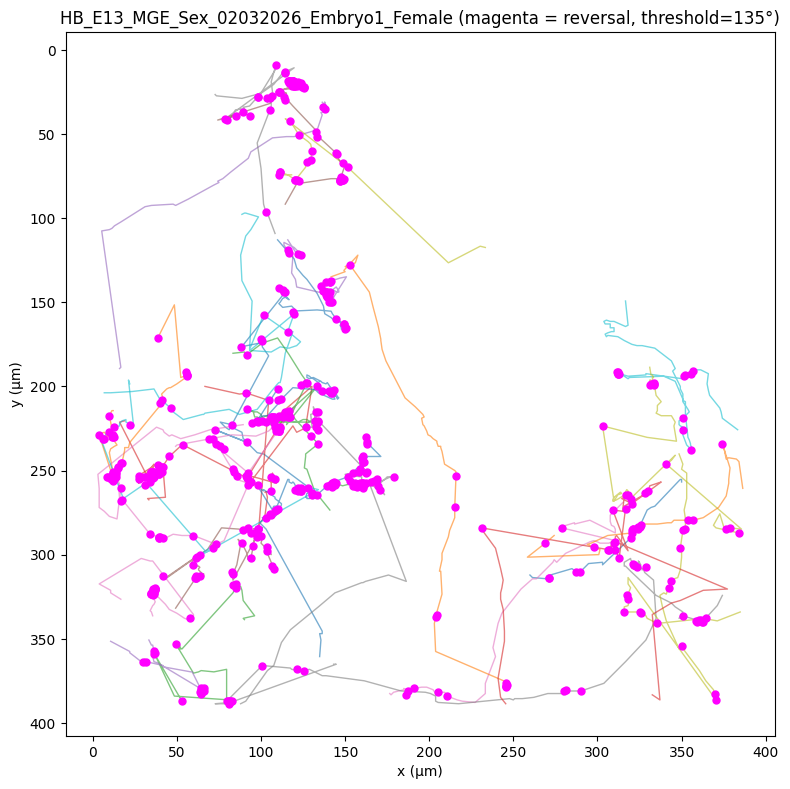

  Tracks meeting duration cutoff: 32, reversal steps: 533

HB_E13_MGE_Sex_02032026_Embryo2_Male
  Calibration: 2.6400 px/µm, 129 frames


100%|██████████| 4/4 [00:00<00:00,  7.46it/s]


    frame 1/129: 20 objects


100%|██████████| 4/4 [00:00<00:00,  7.89it/s]


    frame 2/129: 18 objects


...

100%|██████████| 4/4 [00:00<00:00,  9.19it/s]


    frame 128/129: 24 objects


100%|██████████| 4/4 [00:00<00:00,  7.66it/s]


    frame 129/129: 29 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo2_Male_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
3808362669.py (24): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


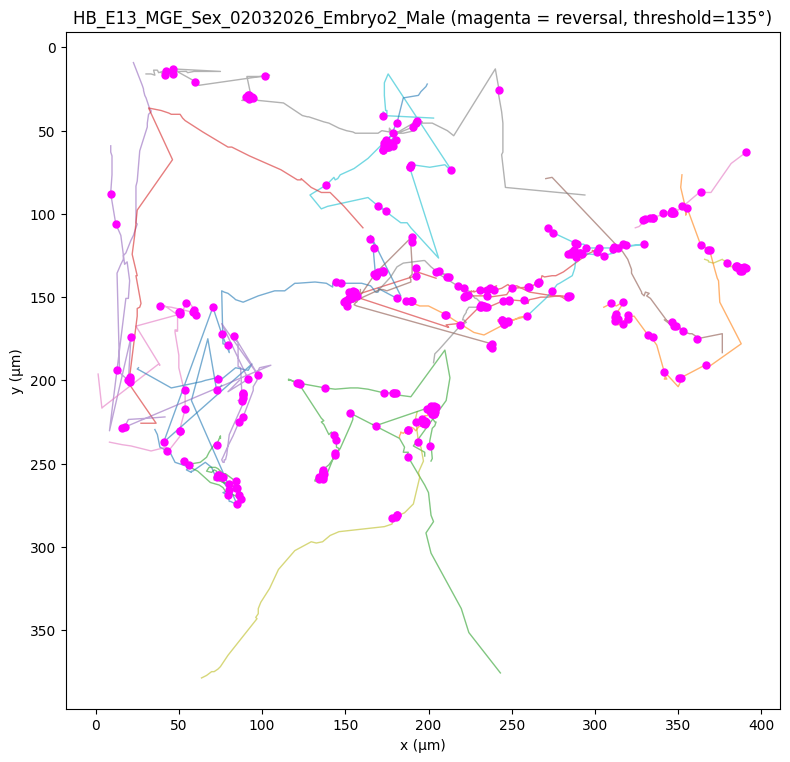

  Tracks meeting duration cutoff: 23, reversal steps: 325

HB_E13_MGE_Sex_02032026_Embryo3_Male
  Calibration: 2.6400 px/µm, 129 frames


100%|██████████| 4/4 [00:00<00:00,  7.87it/s]


    frame 1/129: 29 objects


100%|██████████| 4/4 [00:00<00:00,  7.94it/s]


    frame 2/129: 33 objects


...

100%|██████████| 4/4 [00:00<00:00,  8.11it/s]


    frame 128/129: 37 objects


100%|██████████| 4/4 [00:00<00:00,  9.48it/s]


    frame 129/129: 42 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo3_Male_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
3808362669.py (24): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


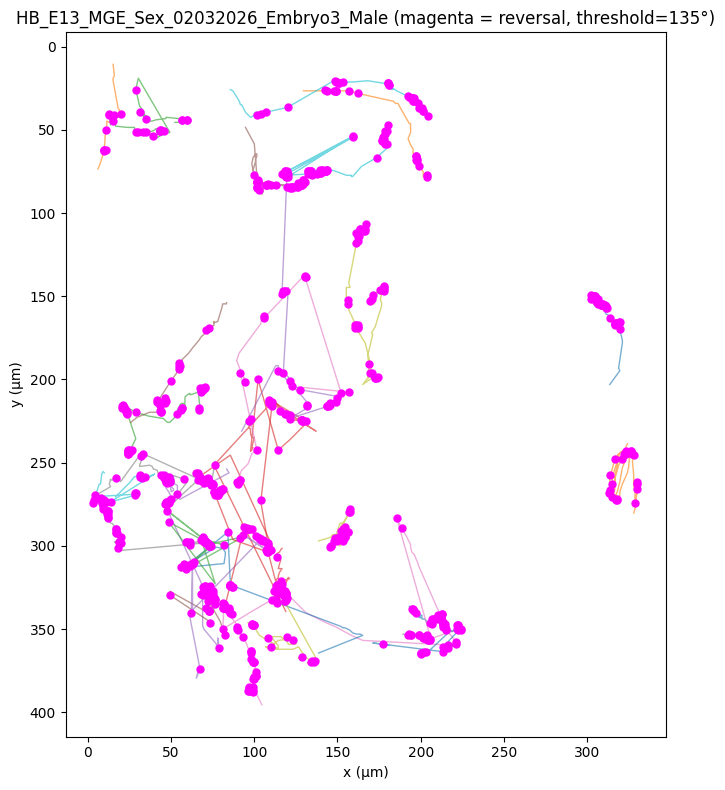

  Tracks meeting duration cutoff: 31, reversal steps: 840

HB_E13_MGE_Sex_02032026_Embryo4_Female
  Calibration: 2.6400 px/µm, 129 frames


100%|██████████| 4/4 [00:00<00:00,  7.81it/s]


    frame 1/129: 17 objects


100%|██████████| 4/4 [00:00<00:00,  8.10it/s]


    frame 2/129: 15 objects


...

100%|██████████| 4/4 [00:00<00:00, 10.26it/s]


    frame 128/129: 23 objects


100%|██████████| 4/4 [00:00<00:00, 10.28it/s]


    frame 129/129: 20 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo4_Female_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
3808362669.py (24): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


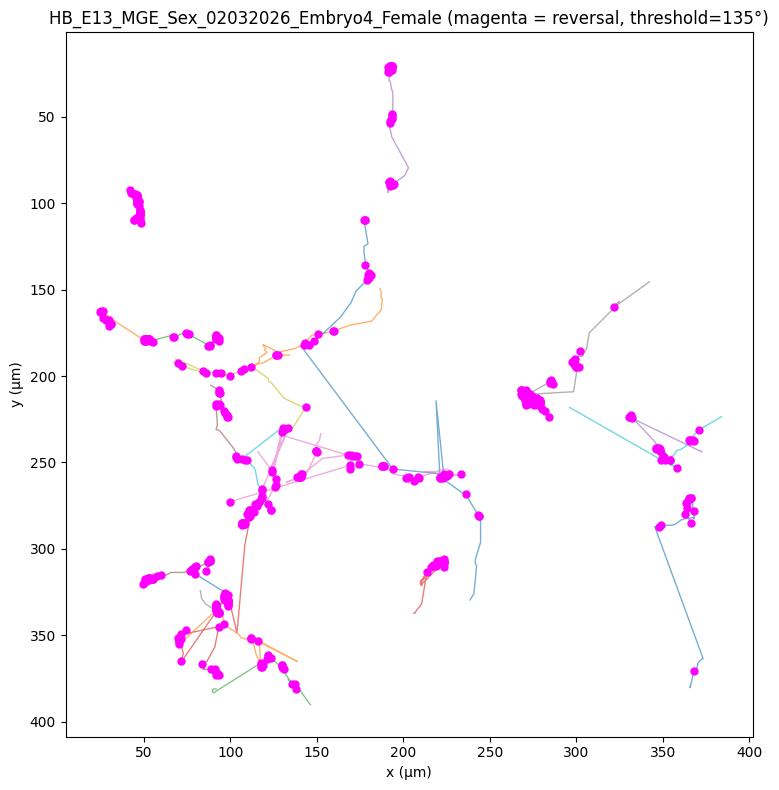

  Tracks meeting duration cutoff: 23, reversal steps: 517

HB_E13_MGE_Sex_02032026_Embryo5_Female
  Calibration: 2.6400 px/µm, 129 frames


100%|██████████| 4/4 [00:00<00:00,  7.60it/s]


    frame 1/129: 39 objects


100%|██████████| 4/4 [00:00<00:00,  7.82it/s]


    frame 2/129: 38 objects


...

100%|██████████| 4/4 [00:00<00:00, 10.83it/s]


    frame 128/129: 77 objects


100%|██████████| 4/4 [00:00<00:00, 10.89it/s]


    frame 129/129: 82 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo5_Female_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
3808362669.py (24): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


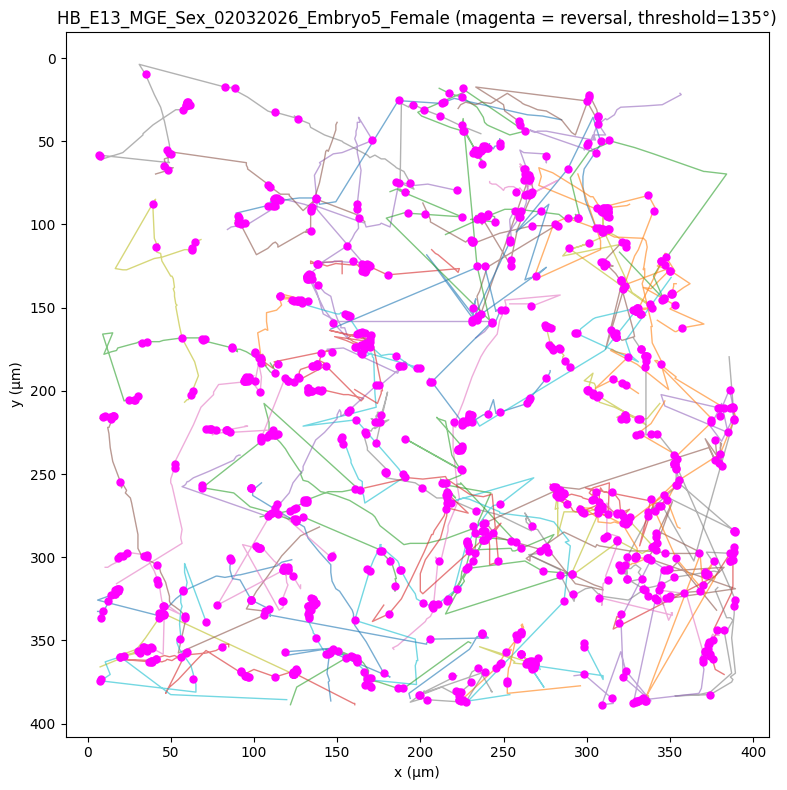

  Tracks meeting duration cutoff: 69, reversal steps: 1031

HB_E13_MGE_Sex_02032026_Embryo6_Male
  Calibration: 2.6400 px/µm, 129 frames


100%|██████████| 4/4 [00:03<00:00,  1.03it/s]


    frame 1/129: 34 objects


100%|██████████| 4/4 [00:00<00:00, 11.85it/s]


    frame 2/129: 40 objects


...

100%|██████████| 4/4 [00:00<00:00,  9.97it/s]


    frame 128/129: 38 objects


100%|██████████| 4/4 [00:00<00:00,  9.75it/s]


    frame 129/129: 41 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo6_Male_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
3808362669.py (24): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


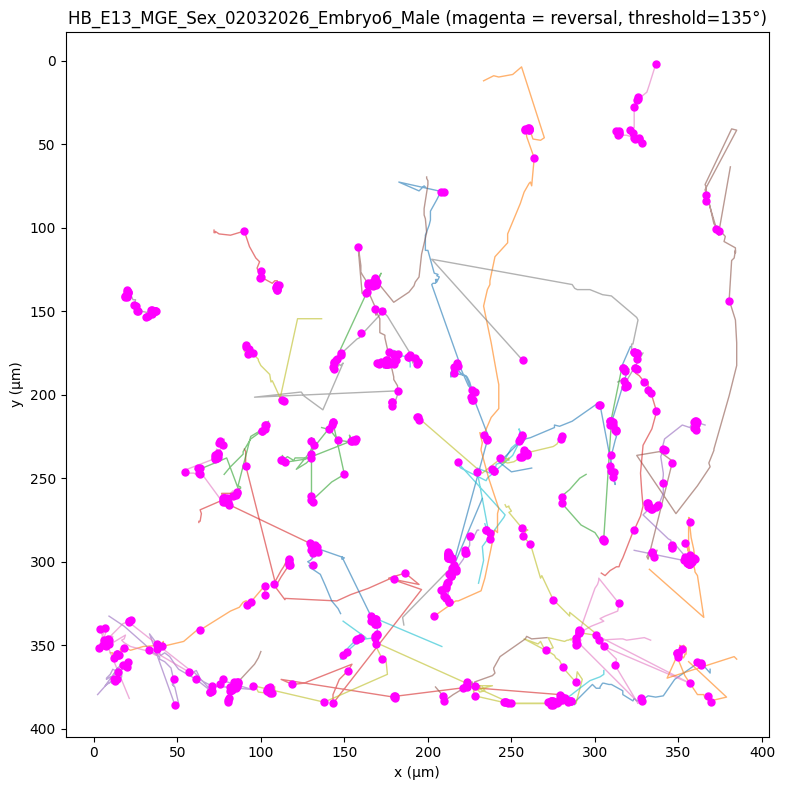

  Tracks meeting duration cutoff: 40, reversal steps: 580

HB_E13_MGE_Sex_02032026_Embryo7_Male
  Calibration: 2.6400 px/µm, 129 frames


100%|██████████| 4/4 [00:00<00:00,  7.76it/s]


    frame 1/129: 6 objects


100%|██████████| 4/4 [00:00<00:00,  7.78it/s]


    frame 2/129: 5 objects


...

100%|██████████| 4/4 [00:00<00:00,  9.79it/s]


    frame 128/129: 11 objects


100%|██████████| 4/4 [00:00<00:00, 10.31it/s]


    frame 129/129: 11 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo7_Male_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
3808362669.py (24): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


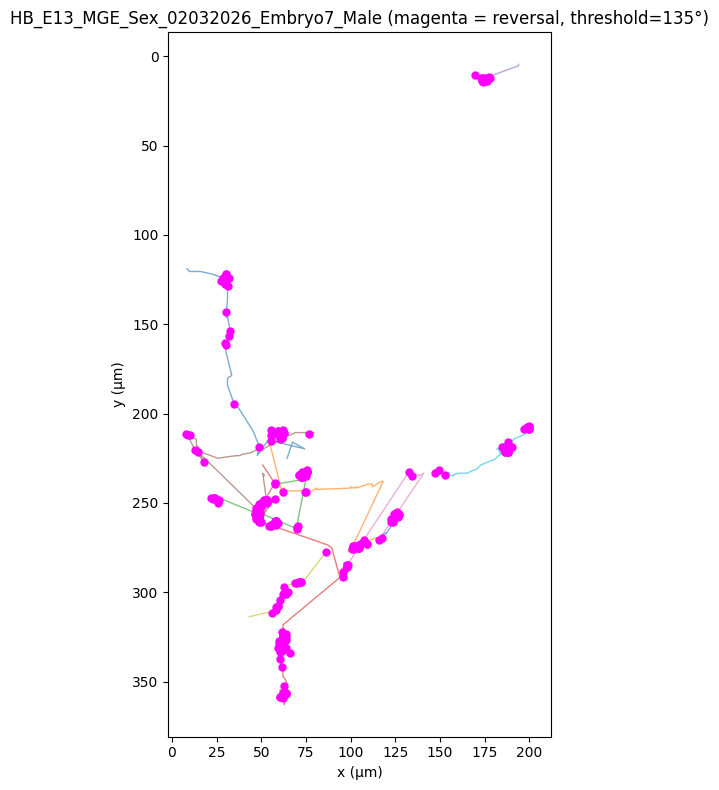

  Tracks meeting duration cutoff: 11, reversal steps: 294

HB_E13_MGE_Sex_02032026_Embryo8_Female
  Calibration: 2.6400 px/µm, 129 frames


100%|██████████| 4/4 [00:00<00:00,  7.31it/s]


    frame 1/129: 13 objects


100%|██████████| 4/4 [00:00<00:00,  8.06it/s]


    frame 2/129: 14 objects


...

100%|██████████| 4/4 [00:00<00:00, 10.57it/s]


    frame 128/129: 23 objects


100%|██████████| 4/4 [00:00<00:00, 10.54it/s]


    frame 129/129: 23 objects
  Segmentation saved: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/HB_E13_MGE_Sex_02032026_Embryo8_Female_stardist_segmentation.tif


2803833429.py (28): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
3808362669.py (24): DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


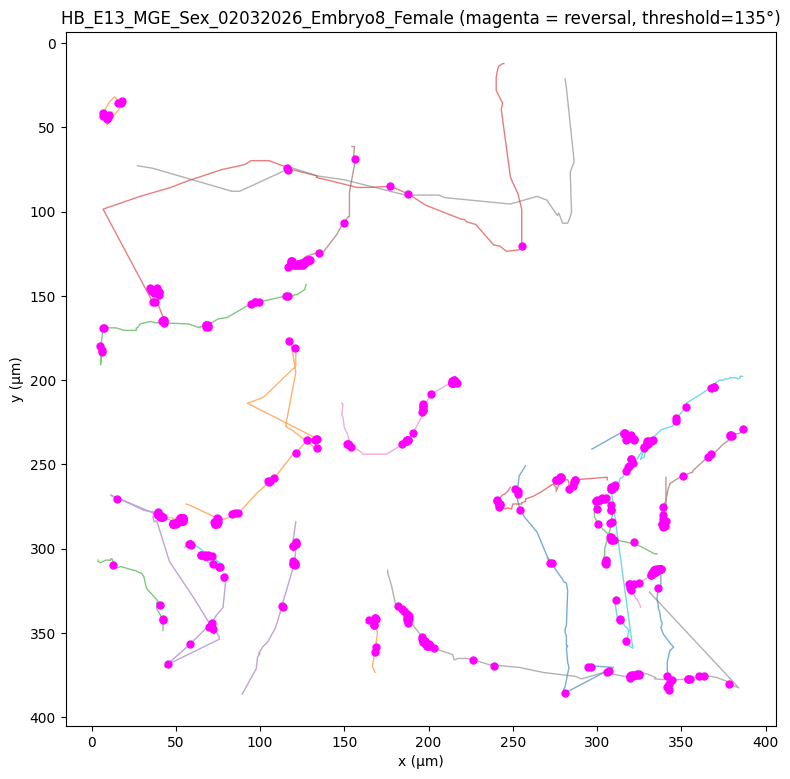

  Tracks meeting duration cutoff: 23, reversal steps: 443

BATCH COMPLETE
Processed: 8 / 8


In [17]:
#Run the batch analysis

all_tracks = []
all_summaries = []
failed_files = []

for input_path in input_paths:
    try:
        tracks_df, track_summary = process_single_movie(
    input_path, model, OUTPUT_DIR,
    MAX_DISPLACEMENT_UM, REVERSAL_ANGLE_THRESHOLD_DEG, n_tiles=N_TILES,
    max_frame_gap=MAX_FRAME_GAP,
    pause_threshold_um=PAUSE_THRESHOLD_UM,
    nucleokinesis_threshold_um=NUCLEOKINESIS_THRESHOLD_UM,
    min_track_duration_hours=MIN_TRACK_DURATION_HOURS,
)
        all_tracks.append(tracks_df)
        all_summaries.append(track_summary)
    except Exception as e:
        print(f"  FAILED: {os.path.basename(input_path)} -> {e}")
        failed_files.append((input_path, str(e)))

print("\n================================")
print("BATCH COMPLETE")
print("================================")
print(f"Processed: {len(all_tracks)} / {len(input_paths)}")
if failed_files:
    print("Failed files:")
    for p, err in failed_files:
        print(" ", os.path.basename(p), "-", err)

In [18]:
#Combine tracks across all movies


combined_tracks_df = pd.concat(all_tracks, ignore_index=True) if all_tracks else pd.DataFrame()
combined_summary_df = pd.concat(all_summaries, ignore_index=True) if all_summaries else pd.DataFrame()

combined_tracks_path = os.path.join(OUTPUT_DIR, "all_movies_tracks.csv")
combined_summary_path = os.path.join(OUTPUT_DIR, "all_movies_track_summary.csv")

combined_tracks_df.to_csv(combined_tracks_path, index=False)
combined_summary_df.to_csv(combined_summary_path, index=False)

print("Combined per-detection table:", combined_tracks_path)
print("Combined per-track summary:  ", combined_summary_path)

if not combined_summary_df.empty:
    print("\nReversals per movie:")
    print(combined_summary_df.groupby("movie")["n_reversals"].sum())

Combined per-detection table: /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/all_movies_tracks.csv
Combined per-track summary:   /mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/all_movies_track_summary.csv

Reversals per movie:
movie
HB_E13_MGE_Sex_02032026_Embryo1_Female     533.0
HB_E13_MGE_Sex_02032026_Embryo2_Male       325.0
HB_E13_MGE_Sex_02032026_Embryo3_Male       840.0
HB_E13_MGE_Sex_02032026_Embryo4_Female     517.0
HB_E13_MGE_Sex_02032026_Embryo5_Female    1031.0
HB_E13_MGE_Sex_02032026_Embryo6_Male       580.0
HB_E13_MGE_Sex_02032026_Embryo7_Male       294.0
HB_E13_MGE_Sex_02032026_Embryo8_Female     443.0
Name: n_reversals, dtype: float64


In [23]:
#Condition assignment for data comparisons and stats

from scipy import stats

CONDITION_TOKENS = ["Male", "Female"]
CASE_SENSITIVE = False

combined_summary_df = assign_conditions_from_filename(
    combined_summary_df,
    CONDITION_TOKENS,
    case_sensitive=CASE_SENSITIVE
)

def assign_conditions_from_filename(df, tokens, case_sensitive=False, movie_col="movie"):
    """
    Assigns a condition by matching whole underscore-separated segments of
    the filename against the token list - e.g. "..._Female_..." matches the
    "Female" segment exactly, so "Male" won't accidentally match inside it.
    """
    df = df.copy()

    def find_condition(movie_name):
        segments = movie_name.split("_")
        if not case_sensitive:
            segments = [s.lower() for s in segments]
            compare_tokens = [t.lower() for t in tokens]
        else:
            compare_tokens = tokens

        matches = [t for t, t_cmp in zip(tokens, compare_tokens) if t_cmp in segments]
        return matches[0] if len(matches) == 1 else np.nan

    df["condition"] = df[movie_col].apply(find_condition)
    unmatched = df.loc[df["condition"].isna(), movie_col].unique()
    if len(unmatched) > 0:
        print("WARNING: could not assign a single condition to these movies:")
        for m in unmatched:
            print("  ", m)
    return df

In [25]:
METRIC_COLUMNS = ['velocity_um_per_hour', 'nucleokinesis_frequency_per_hour', 'mean_nucleokinesis_amplitude', 'reversal_frequency_per_hour', 
'avg_reversal_angle_deg', 'straightness_index', 'pause_percentage']

STATS_OUTPUT_DIR = "/mnt/c/Users/hbruce/Desktop/stardist_cIN_model/output/stats" #Change accordingly
os.makedirs(STATS_OUTPUT_DIR, exist_ok=True)

ALPHA = 0.05

In [26]:
#Visualise per-movie n breakdown so you can see track counts and movie counts side by side.
#This is imporant for stats: currently most people in the lab treat each track/neuron as an n
#It is more appropriate to treat each experiment as an n 

print("Tracks per movie:")
print(combined_summary_df.groupby(["condition", "movie"])["track_id"].count())

print("\nMovies per condition:")
print(combined_summary_df.groupby("condition")["movie"].nunique())

print("\nTracks per condition (track-level n):")
print(combined_summary_df.groupby("condition")["track_id"].count())

Tracks per movie:
condition  movie                                 
Female     HB_E13_MGE_Sex_02032026_Embryo1_Female    32
           HB_E13_MGE_Sex_02032026_Embryo4_Female    23
           HB_E13_MGE_Sex_02032026_Embryo5_Female    69
           HB_E13_MGE_Sex_02032026_Embryo8_Female    23
Male       HB_E13_MGE_Sex_02032026_Embryo2_Male      23
           HB_E13_MGE_Sex_02032026_Embryo3_Male      31
           HB_E13_MGE_Sex_02032026_Embryo6_Male      40
           HB_E13_MGE_Sex_02032026_Embryo7_Male      11
Name: track_id, dtype: int64

Movies per condition:
condition
Female    4
Male      4
Name: movie, dtype: int64

Tracks per condition (track-level n):
condition
Female    147
Male      105
Name: track_id, dtype: int64


In [27]:
#Average tracks across a single move

def aggregate_by_movie(df, metric_columns, movie_col="movie", group_col="condition"):
    """
    Collapses track-level data to one row per movie by averaging each metric
    across that movie's tracks. This makes the movie (not the track) the
    unit of replication - the statistically appropriate level when tracks
    from the same movie aren't independent of each other.
    """
    agg_dict = {m: "mean" for m in metric_columns}
    movie_df = (
        df.groupby([movie_col, group_col])
        .agg(agg_dict)
        .reset_index()
    )
    n_tracks = df.groupby([movie_col, group_col]).size().reset_index(name="n_tracks")
    movie_df = movie_df.merge(n_tracks, on=[movie_col, group_col])
    return movie_df


movie_level_df = aggregate_by_movie(combined_summary_df, METRIC_COLUMNS)
print(movie_level_df)

                                    movie condition  velocity_um_per_hour  \
0  HB_E13_MGE_Sex_02032026_Embryo1_Female    Female             33.614068   
1    HB_E13_MGE_Sex_02032026_Embryo2_Male      Male             34.566226   
2    HB_E13_MGE_Sex_02032026_Embryo3_Male      Male             22.111031   
3  HB_E13_MGE_Sex_02032026_Embryo4_Female    Female             18.091647   
4  HB_E13_MGE_Sex_02032026_Embryo5_Female    Female             38.286730   
5    HB_E13_MGE_Sex_02032026_Embryo6_Male      Male             30.157043   
6    HB_E13_MGE_Sex_02032026_Embryo7_Male      Male             16.422871   
7  HB_E13_MGE_Sex_02032026_Embryo8_Female    Female             20.097805   

   nucleokinesis_frequency_per_hour  mean_nucleokinesis_amplitude  \
0                          1.539013                     15.863360   
1                          1.662725                     14.071967   
2                          0.827773                     16.746378   
3                          0.6

In [28]:
#Nested model allowing for use of multiple tracks, while keeping the statistics proper

import statsmodels.formula.api as smf

def run_nested_model(df, metric, movie_col="movie", group_col="condition", alpha=0.05):
    """
    Fits metric ~ condition with movie as a random intercept, using every
    individual track (no averaging). The random intercept for movie soaks
    up movie-to-movie baseline differences, so the condition effect is
    tested against between-movie variability rather than inflated by
    within-movie replication.

    2 conditions -> Wald test on the condition coefficient.
    >2 conditions -> likelihood ratio test (full model vs. movie-only model).
    """
    data = df[[metric, group_col, movie_col]].dropna().copy()
    data[group_col] = data[group_col].astype("category")
    n_conditions = data[group_col].nunique()
    n_movies = data[movie_col].nunique()

    if n_conditions < 2 or n_movies < 2:
        return {"metric": metric, "n_conditions": n_conditions, "n_movies": n_movies,
                "n_tracks": len(data), "test": "skipped (insufficient groups/movies)",
                "statistic": np.nan, "p_value": np.nan, "significant": np.nan}

    full_result = smf.mixedlm(f"{metric} ~ {group_col}", data, groups=data[movie_col]).fit(reml=False)

    if n_conditions == 2:
        coef_name = [c for c in full_result.params.index if c.startswith(group_col)][0]
        statistic = full_result.tvalues[coef_name]
        p_value = full_result.pvalues[coef_name]
        test_name = "Mixed model (Wald test, movie random intercept)"
    else:
        reduced_result = smf.mixedlm(f"{metric} ~ 1", data, groups=data[movie_col]).fit(reml=False)
        lr_stat = 2 * (full_result.llf - reduced_result.llf)
        df_diff = n_conditions - 1
        p_value = stats.chi2.sf(lr_stat, df_diff)
        statistic = lr_stat
        test_name = "Mixed model (likelihood ratio test, movie random intercept)"

    return {
        "metric": metric, "n_conditions": n_conditions, "n_movies": n_movies,
        "n_tracks": len(data), "test": test_name,
        "statistic": statistic, "p_value": p_value, "significant": p_value < alpha,
    }


def run_nested_comparisons(df, metric_columns, movie_col="movie", group_col="condition", alpha=0.05):
    return pd.DataFrame([run_nested_model(df, m, movie_col, group_col, alpha) for m in metric_columns])

In [29]:
#Residual normality 
def check_residual_normality(df, metric, movie_col="movie", group_col="condition"):
    data = df[[metric, group_col, movie_col]].dropna().copy()
    if data[group_col].nunique() < 2 or data[movie_col].nunique() < 2 or len(data) < 3:
        return {"metric": metric, "W": np.nan, "p_value": np.nan, "residuals_normal": np.nan}
    model = smf.mixedlm(f"{metric} ~ {group_col}", data, groups=data[movie_col]).fit(reml=False)
    W, p = stats.shapiro(model.resid)
    return {"metric": metric, "W": W, "p_value": p, "residuals_normal": p > ALPHA}


def check_all_residual_normality(df, metric_columns):
    return pd.DataFrame([check_residual_normality(df, m) for m in metric_columns])

In [30]:
#Test data for normality 

def test_normality(df, metric_columns, group_col="condition", alpha=0.05):
    """Shapiro-Wilk normality test per (condition, metric). Needs n>=3 per group."""
    rows = []
    for metric in metric_columns:
        for condition, group in df.groupby(group_col):
            values = group[metric].dropna()
            n = len(values)
            if n < 3:
                rows.append({"metric": metric, "condition": condition, "n": n,
                             "W": np.nan, "p_value": np.nan, "is_normal": np.nan})
                continue
            W, p = stats.shapiro(values)
            rows.append({"metric": metric, "condition": condition, "n": n,
                         "W": W, "p_value": p, "is_normal": p > alpha})
    return pd.DataFrame(rows)


def summarize_by_condition(df, metric_columns, group_col="condition"):
    rows = []
    for metric in metric_columns:
        for condition, group in df.groupby(group_col):
            values = group[metric].dropna()
            rows.append({
                "metric": metric,
                "condition": condition,
                "n": len(values),
                "mean": values.mean(),
                "sem": values.sem() if len(values) > 1 else np.nan,
                "std": values.std(),
                "median": values.median(),
                "iqr": (values.quantile(0.75) - values.quantile(0.25)) if len(values) > 0 else np.nan,
            })
    return pd.DataFrame(rows)

In [31]:
#automatic determination of appropriate statistical tests

def run_group_comparisons(df, metric_columns, normality_df, group_col="condition", alpha=0.05):
    """
    2 conditions: Welch's t-test if both groups pass Shapiro-Wilk, else Mann-Whitney U.
    >2 conditions: one-way ANOVA if all groups pass Shapiro-Wilk, else Kruskal-Wallis.
    A group with an unknown/failed normality result (n<3) is treated as non-normal,
    so the safer non-parametric test is used when in doubt.
    """
    conditions = sorted(df[group_col].dropna().unique())
    n_conditions = len(conditions)

    if n_conditions < 2:
        print("Only one condition present - nothing to compare.")
        return pd.DataFrame()

    results = []
    for metric in metric_columns:
        groups = [df.loc[df[group_col] == c, metric].dropna() for c in conditions]

        if any(len(g) < 2 for g in groups):
            results.append({"metric": metric, "n_conditions": n_conditions,
                             "conditions": ", ".join(conditions),
                             "test": "skipped (insufficient data)",
                             "statistic": np.nan, "p_value": np.nan, "significant": np.nan})
            continue

        all_normal = normality_df.loc[normality_df["metric"] == metric, "is_normal"].fillna(False).all()

        if n_conditions == 2:
            if all_normal:
                stat, p = stats.ttest_ind(groups[0], groups[1], equal_var=False)
                test_name = "Welch's t-test"
            else:
                stat, p = stats.mannwhitneyu(groups[0], groups[1], alternative="two-sided")
                test_name = "Mann-Whitney U"
        else:
            if all_normal:
                stat, p = stats.f_oneway(*groups)
                test_name = "One-way ANOVA"
            else:
                stat, p = stats.kruskal(*groups)
                test_name = "Kruskal-Wallis"

        results.append({"metric": metric, "n_conditions": n_conditions,
                         "conditions": ", ".join(conditions), "test": test_name,
                         "statistic": stat, "p_value": p, "significant": p < alpha})

    return pd.DataFrame(results)

In [32]:
#Plotting data

def plot_condition_comparisons(df, metric_columns, comparison_df, group_col="condition", save_path=None):
    conditions = sorted(df[group_col].dropna().unique())   
    n_cols = 3
    n_rows = int(np.ceil(len(metric_columns) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
    axes = np.atleast_1d(axes).flatten()
    condition_colors = {"Female": "#9AD9D0","Male": "#E6A1C5"}
    rng = np.random.default_rng(0)

    for ax, metric in zip(axes, metric_columns):
        data = [df.loc[df[group_col] == c, metric].dropna().values for c in conditions]
        ax.boxplot(data, labels=conditions, showfliers=False)

        for i, values in enumerate(data, start=1):
            jitter = rng.normal(loc=i, scale=0.04, size=len(values))
            ax.scatter(jitter, values, alpha=0.6, s=15, color="black", zorder=3)

        p_row = comparison_df.loc[comparison_df["metric"] == metric]
        if len(p_row) > 0 and pd.notna(p_row["p_value"].values[0]):
            ax.set_title(f"{metric}\n{p_row['test'].values[0]}, p={p_row['p_value'].values[0]:.4g}")
        else:
            ax.set_title(metric)
        ax.set_ylabel(metric)

    for ax in axes[len(metric_columns):]:
        ax.axis("off")

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150)
    plt.show()
    

In [33]:
def plot_condition_comparisons(df, metric_columns, comparison_df,
                               group_col="condition", save_path=None):

    conditions = ["Female", "Male"]
    conditions = [c for c in conditions if c in df[group_col].dropna().unique()]

    n_cols = 3
    n_rows = int(np.ceil(len(metric_columns) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4.5 * n_rows)
    )

    axes = np.atleast_1d(axes).flatten()

    # Pastel colours
    condition_colors = {
        "Female": "#9AD9D0",   # light teal
        "Male": "#E6A1C5"      # light magenta
    }

    rng = np.random.default_rng(0)

    for ax, metric in zip(axes, metric_columns):

        data = [
            df.loc[df[group_col] == c, metric].dropna().values
            for c in conditions
        ]

        # Violin plot
        vp = ax.violinplot(
            data,
            positions=np.arange(1, len(conditions) + 1),
            showmeans=False,
            showmedians=True,
            showextrema=False
        )

        # Colour each violin
        for body, condition in zip(vp["bodies"], conditions):
            body.set_facecolor(condition_colors[condition])
            body.set_edgecolor("black")
            body.set_alpha(0.65)

        # Median lines
        if "cmedians" in vp:
            vp["cmedians"].set_color("black")
            vp["cmedians"].set_linewidth(1.5)

        # Individual data points
        for i, (condition, values) in enumerate(
            zip(conditions, data),
            start=1
        ):
            jitter = rng.normal(
                loc=i,
                scale=0.04,
                size=len(values)
            )

            ax.scatter(
                jitter,
                values,
                alpha=0.45,
                s=15,
                color=condition_colors[condition],
                edgecolor="white",
                linewidth=0.4,
                zorder=3
            )

        # Statistical result
        p_row = comparison_df.loc[
            comparison_df["metric"] == metric
        ]

        if len(p_row) > 0 and pd.notna(
            p_row["p_value"].values[0]
        ):
            ax.set_title(
                f"{metric}\n"
                f"{p_row['test'].values[0]}, "
                f"p={p_row['p_value'].values[0]:.4g}"
            )
        else:
            ax.set_title(metric)

        ax.set_xticks(np.arange(1, len(conditions) + 1))
        ax.set_xticklabels(conditions)

        ax.set_ylabel(metric)

        # Clean appearance
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.yaxis.grid(
            True,
            linestyle="--",
            alpha=0.25
        )
        ax.set_axisbelow(True)

    # Hide unused axes
    for ax in axes[len(metric_columns):]:
        ax.axis("off")

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

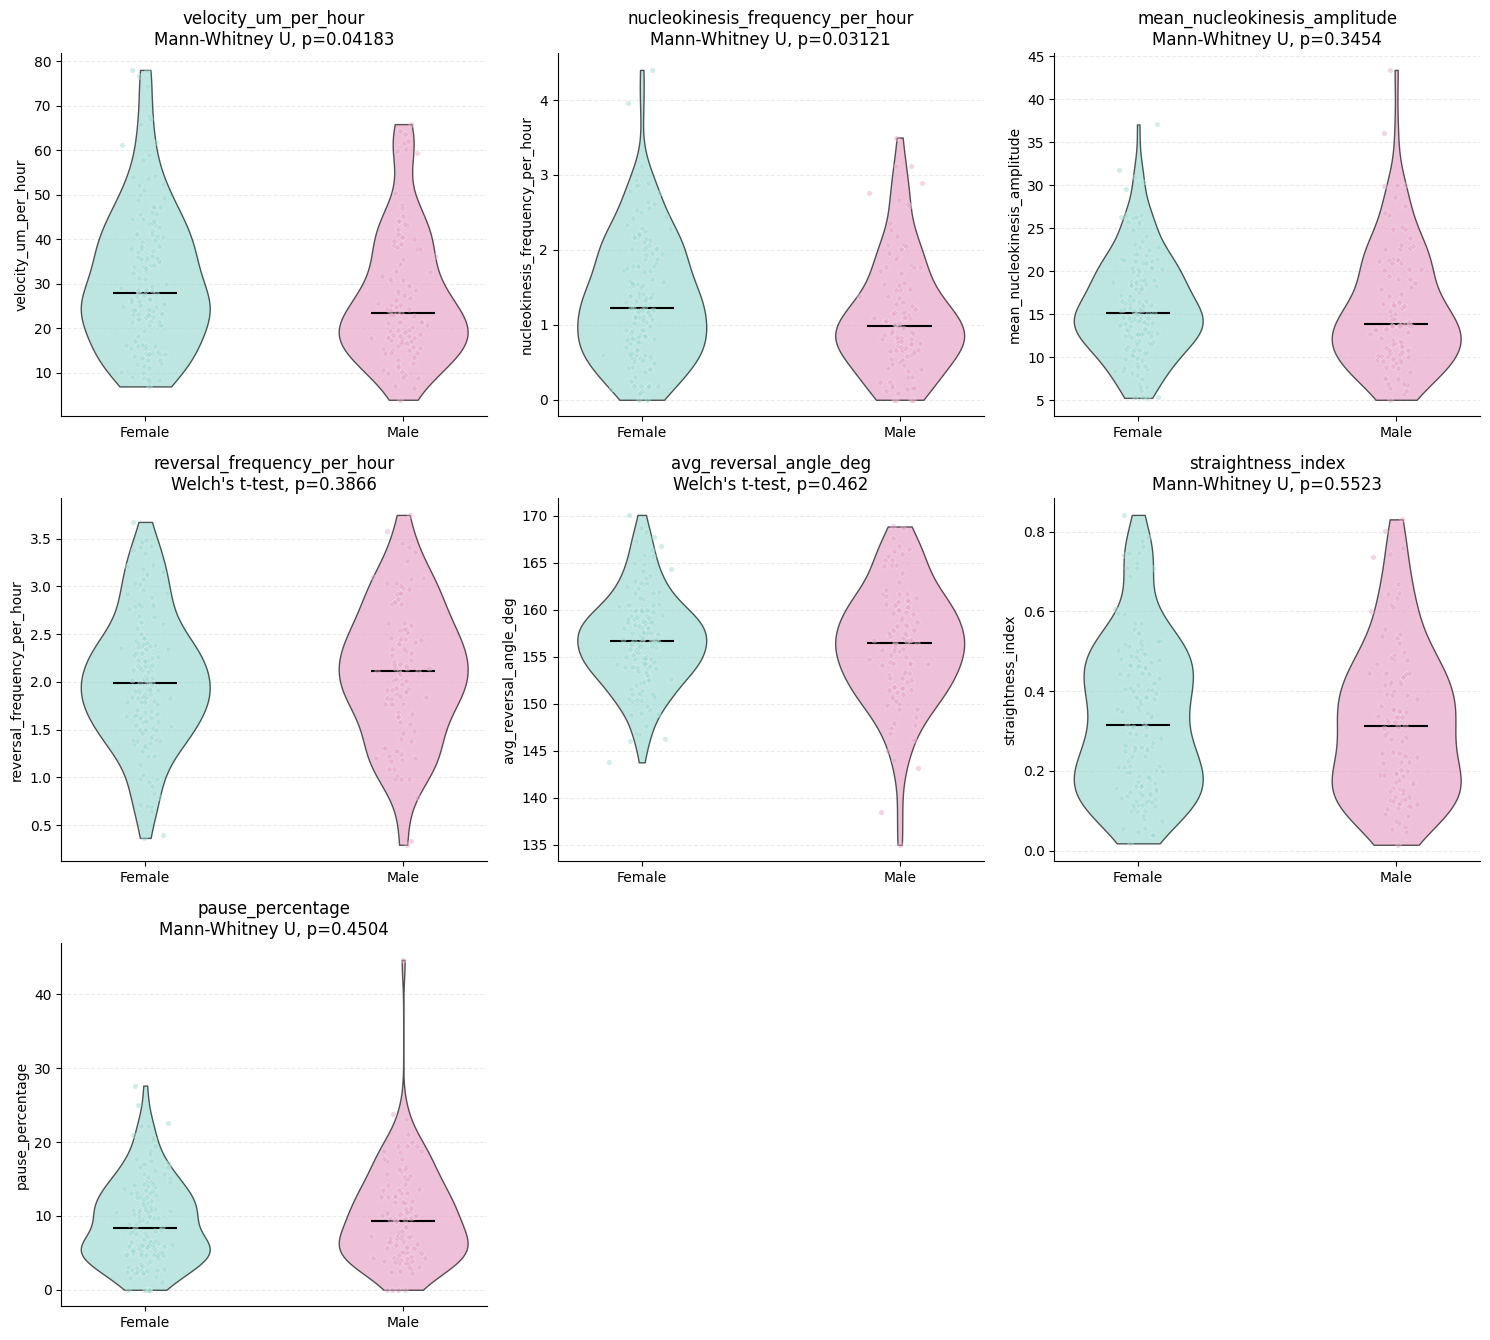


=== TRACK_LEVEL (n reflects tracks) ===
                             metric            test   p_value  significant
0              velocity_um_per_hour  Mann-Whitney U  0.041830         True
1  nucleokinesis_frequency_per_hour  Mann-Whitney U  0.031206         True
2      mean_nucleokinesis_amplitude  Mann-Whitney U  0.345441        False
3       reversal_frequency_per_hour  Welch's t-test  0.386590        False
4            avg_reversal_angle_deg  Welch's t-test  0.462038        False
5                straightness_index  Mann-Whitney U  0.552338        False
6                  pause_percentage  Mann-Whitney U  0.450437        False


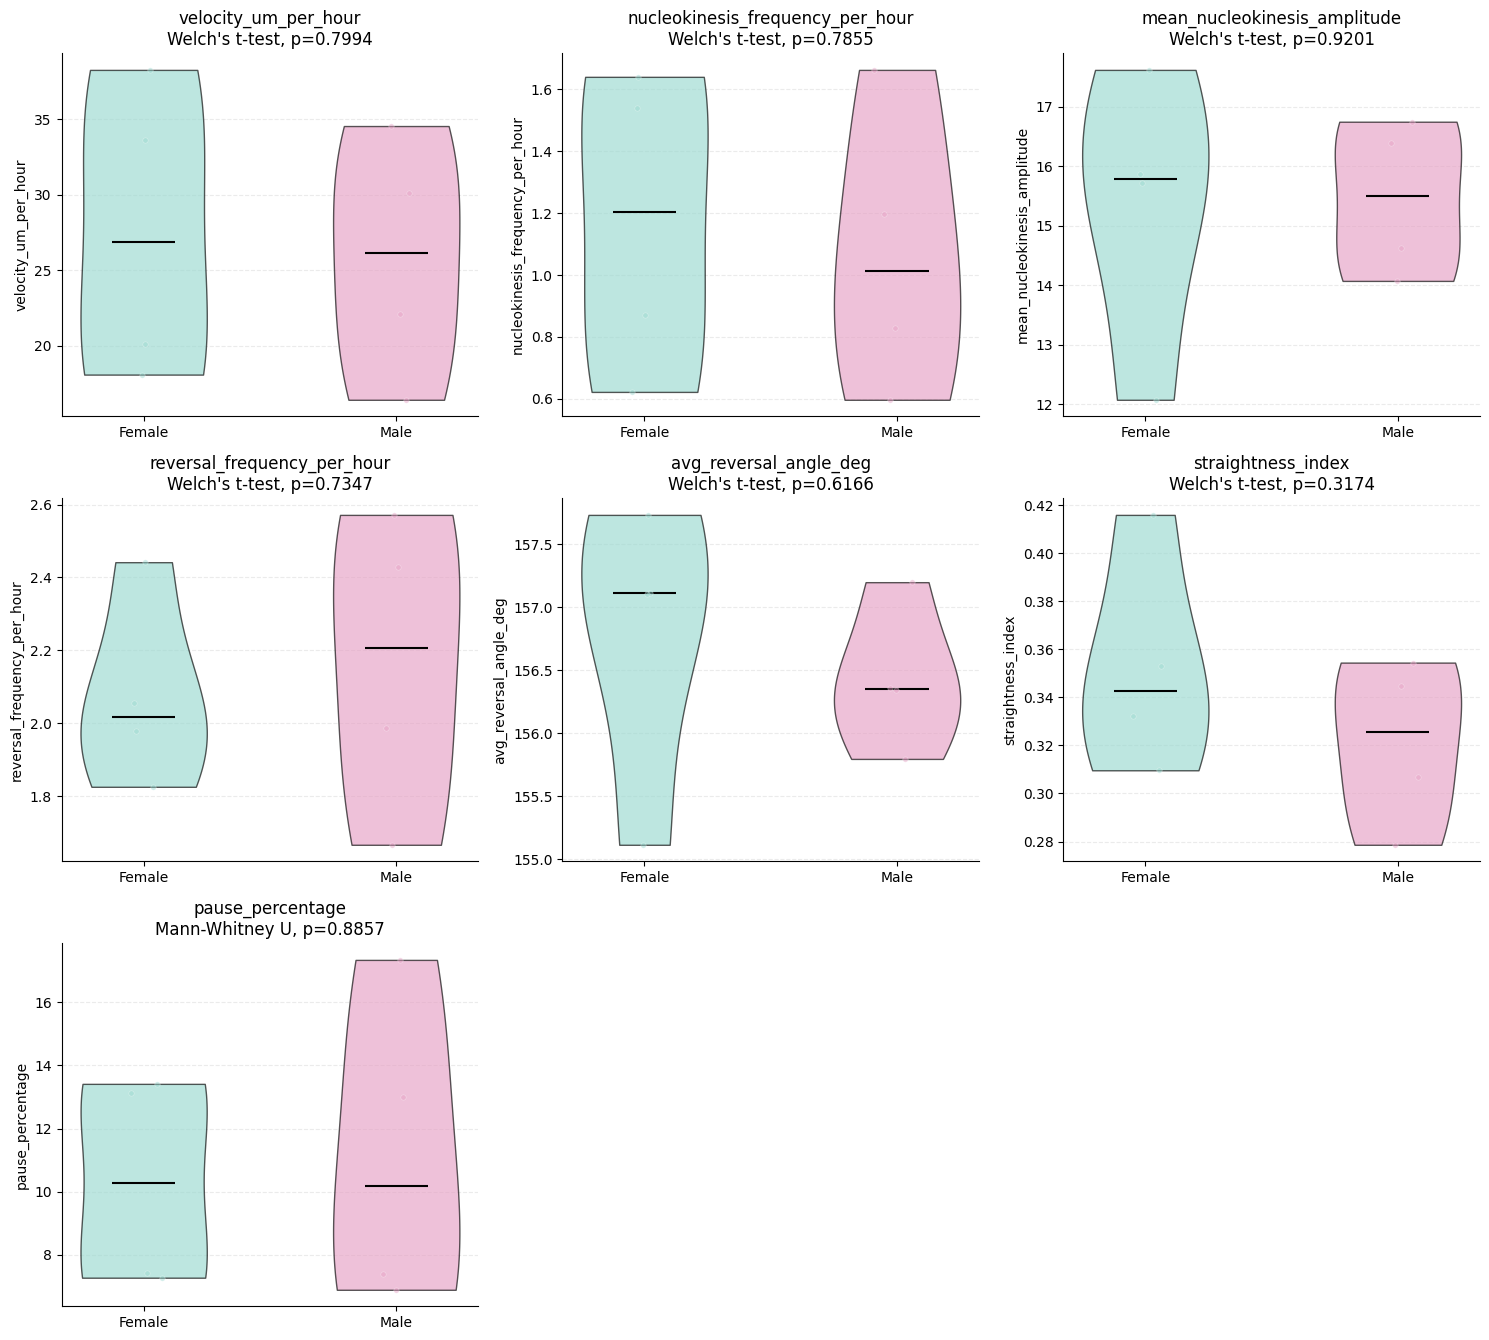


=== MOVIE_LEVEL (n reflects movies) ===
                             metric            test   p_value  significant
0              velocity_um_per_hour  Welch's t-test  0.799395        False
1  nucleokinesis_frequency_per_hour  Welch's t-test  0.785502        False
2      mean_nucleokinesis_amplitude  Welch's t-test  0.920059        False
3       reversal_frequency_per_hour  Welch's t-test  0.734691        False
4            avg_reversal_angle_deg  Welch's t-test  0.616579        False
5                straightness_index  Welch's t-test  0.317417        False
6                  pause_percentage  Mann-Whitney U  0.885714        False


In [34]:
#Run analysis 

def run_full_analysis(df, metric_columns, label, output_dir, alpha=0.05):
    """Runs normality + comparison tests + plot, saving everything with a
    filename suffix identifying which level ('track_level' or 'movie_level')
    the analysis was run at."""
    normality_df = test_normality(df, metric_columns, alpha=alpha)
    descriptive_df = summarize_by_condition(df, metric_columns)
    comparison_df = run_group_comparisons(df, metric_columns, normality_df, alpha=alpha)

    normality_path = os.path.join(output_dir, f"condition_normality_tests_{label}.csv")
    descriptive_path = os.path.join(output_dir, f"condition_summary_stats_{label}.csv")
    comparison_path = os.path.join(output_dir, f"condition_comparison_tests_{label}.csv")
    plot_path = os.path.join(output_dir, f"condition_comparison_plots_{label}.png")

    normality_df.to_csv(normality_path, index=False)
    descriptive_df.to_csv(descriptive_path, index=False)
    comparison_df.to_csv(comparison_path, index=False)
    plot_condition_comparisons(df, metric_columns, comparison_df, save_path=plot_path)

    print(f"\n=== {label.upper()} (n reflects {'tracks' if label=='track_level' else 'movies'}) ===")
    print(comparison_df[["metric", "test", "p_value", "significant"]])

    return normality_df, descriptive_df, comparison_df


track_normality, track_descriptive, track_comparison = run_full_analysis(
    combined_summary_df, METRIC_COLUMNS, "track_level", STATS_OUTPUT_DIR, alpha=ALPHA
)

movie_normality, movie_descriptive, movie_comparison = run_full_analysis(
    movie_level_df, METRIC_COLUMNS, "movie_level", STATS_OUTPUT_DIR, alpha=ALPHA
)